Total Loans: 9578
Fully Paid: 8045
Not Fully Paid: 1533
Non-Repayment Rate: 16.01 %


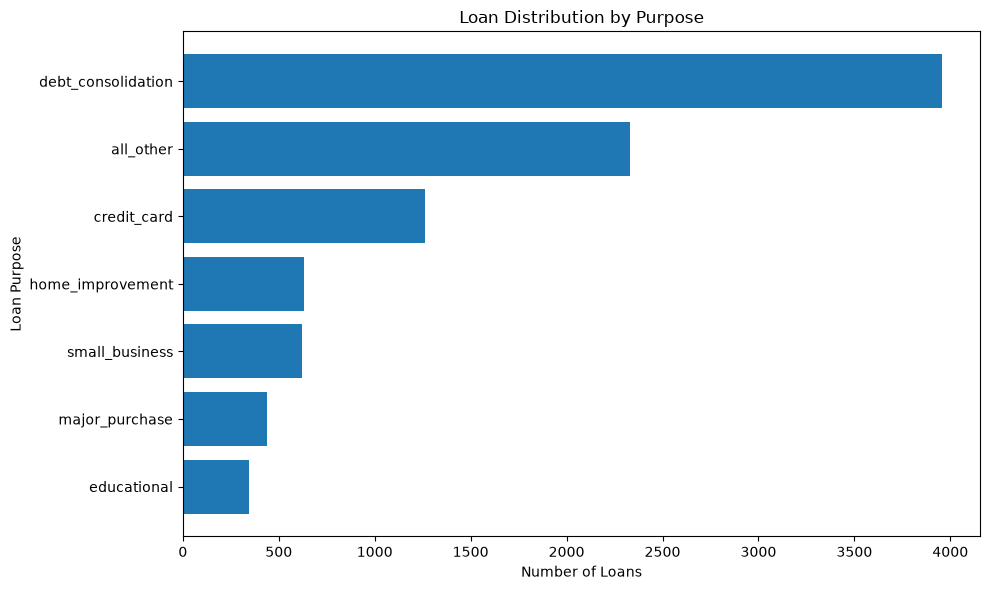

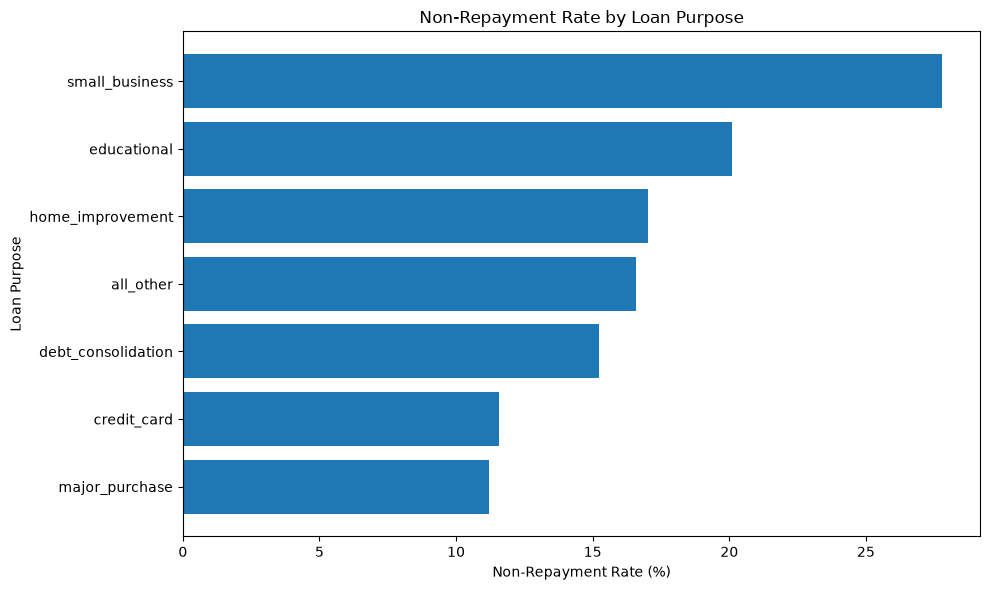

<Figure size 800x600 with 0 Axes>

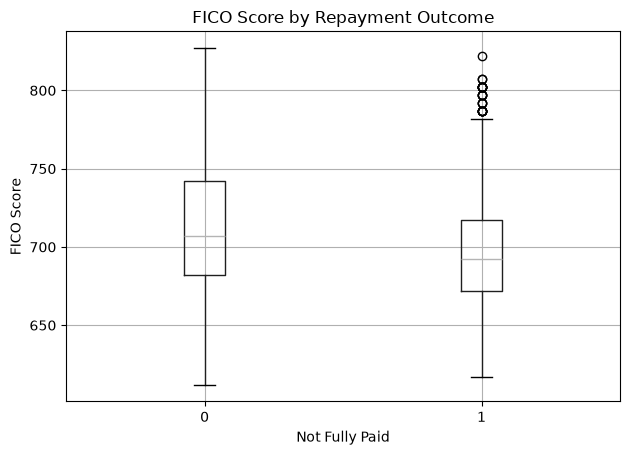

<Figure size 800x600 with 0 Axes>

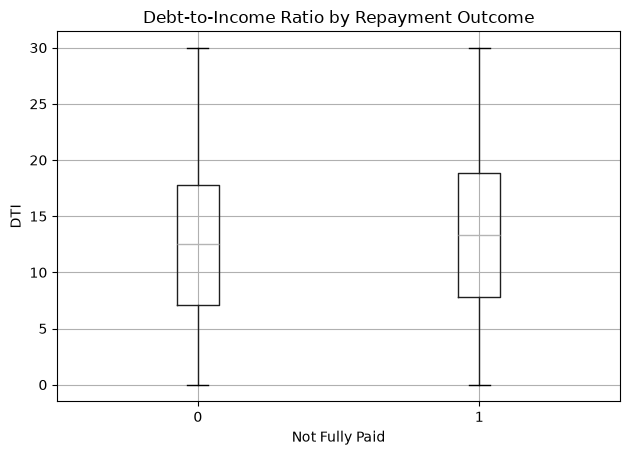

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/loan_data.csv")

df.head()

total_loans = len(df)

fully_paid = (df["not.fully.paid"] == 0).sum()

not_fully_paid = (df["not.fully.paid"] == 1).sum()

non_repayment_rate = (not_fully_paid / total_loans) * 100

print("Total Loans:", total_loans)
print("Fully Paid:", fully_paid)
print("Not Fully Paid:", not_fully_paid)
print("Non-Repayment Rate:", round(non_repayment_rate, 2), "%")

purpose_analysis = (
    df.groupby("purpose")
    .agg(
        total_loans=("not.fully.paid", "count"),
        unpaid_loans=("not.fully.paid", "sum"),
        non_repayment_rate=("not.fully.paid", "mean"),
    )
    .reset_index()
)

purpose_analysis["non_repayment_rate"] *= 100

purpose_analysis = purpose_analysis.sort_values("non_repayment_rate", ascending=False)

purpose_analysis

fico_analysis = (
    df.groupby("not.fully.paid")
    .agg(loan_count=("fico", "count"), average_fico=("fico", "mean"))
    .reset_index()
)

fico_analysis

dti_analysis = (
    df.groupby("not.fully.paid")
    .agg(loan_count=("dti", "count"), average_dti=("dti", "mean"))
    .reset_index()
)

dti_analysis

purpose_counts = df["purpose"].value_counts().sort_values()

plt.figure(figsize=(10, 6))

plt.barh(purpose_counts.index, purpose_counts.values)

plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")
plt.title("Loan Distribution by Purpose")

plt.tight_layout()
plt.show()

purpose_rate = df.groupby("purpose")["not.fully.paid"].mean().sort_values() * 100

plt.figure(figsize=(10, 6))

plt.barh(purpose_rate.index, purpose_rate.values)

plt.xlabel("Non-Repayment Rate (%)")
plt.ylabel("Loan Purpose")
plt.title("Non-Repayment Rate by Loan Purpose")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

df.boxplot(column="fico", by="not.fully.paid")

plt.title("FICO Score by Repayment Outcome")
plt.suptitle("")
plt.xlabel("Not Fully Paid")
plt.ylabel("FICO Score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

df.boxplot(column="dti", by="not.fully.paid")

plt.title("Debt-to-Income Ratio by Repayment Outcome")
plt.suptitle("")
plt.xlabel("Not Fully Paid")
plt.ylabel("DTI")

plt.tight_layout()
plt.show()